<a href="https://colab.research.google.com/github/allengr220/cognitive-ledger/blob/main/longevity/benchmark_dataset_builder_PRscore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PhysioRisk v1 — PhenoAge Benchmark Scoring Notebook

## Purpose
Build and score a clean benchmark cohort for direct comparison between:

- PhysioRisk v1
- TotalRisk
- PhenoAge
- PhenoAgeAccel

## Design
This notebook has two phases:

### Phase 1 — Benchmark dataset construction
Construct benchmark train/test cohorts from the NHANES extended mortality dataset.

Rules:
- preserve `SEQN`
- use temporal split
- require complete Levine panel for PhenoAge benchmarking
- require positive CRP
- prepare a stricter v1-ready subset with complete EXTENDED_16 biomarkers

Outputs:
- `physiorisk_phenoage_benchmark_train.parquet`
- `physiorisk_phenoage_benchmark_test.parquet`
- `physiorisk_phenoage_benchmark_train_v1ready.parquet`
- `physiorisk_phenoage_benchmark_test_v1ready.parquet`

### Phase 2 — Frozen PhysioRisk v1 scoring
Apply the original frozen PhysioRisk v1 pipeline to the v1-ready benchmark subset.

Rules:
- keep scoring logic identical to frozen v1 as much as possible
- do not simplify transforms
- do not merge legacy scored files
- score directly from the benchmark v1-ready inputs

Outputs:
- `benchmark_physiorisk_v1_train_scored.parquet`
- `benchmark_physiorisk_v1_test_scored.parquet`

## Benchmark logic
The final comparison must be performed on the same individuals.

This means:
- PhenoAge and PhenoAgeAccel must be computed on the scored benchmark subset
- train-derived transformations only
- test-only evaluation

## Core comparison target
We want to determine whether PhysioRisk v1 captures mortality-relevant physiological variation comparably to PhenoAge-based measures while remaining substantially less correlated with chronological age.

## Notes
- benchmark base cohort = Levine-complete temporal cohort
- v1-ready cohort = subset additionally complete for PhysioRisk v1 biomarkers
- this notebook is for benchmark construction and scoring only
- final evaluation can be done here or in a separate comparison notebook

## Phase 1 — Build benchmark base cohort

In [1]:
# ============================================================
# Benchmark dataset builder — setup
# Purpose:
#   Build, load, and prep the PhysioRisk vs PhenoAge benchmark
#   cohorts for later v1 scoring.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# === Paths ===
DATA_DIR = Path("/content/drive/MyDrive/LRE/data/pub")

BASE_FP = DATA_DIR / "nhanes_1999_2018_extended_mortality_model_dataset.parquet"

BENCH_TRAIN_FP = DATA_DIR / "physiorisk_phenoage_benchmark_train.parquet"
BENCH_TEST_FP  = DATA_DIR / "physiorisk_phenoage_benchmark_test.parquet"

# === Core variables ===
ID_COL = "SEQN"
TIME_COL = "PERMTH_INT"
EVENT_COL = "MORTSTAT"
AGE_COL = "RIDAGEYR"
SEX_COL = "RIAGENDR"
CYCLE_COL = "cycle_start_year"

# === Levine panel (required for PhenoAge) ===
LEVINE_COLS = [
    "LBXSAL",
    "LBXSCR",
    "LBXGLU",
    "LBXHSCRP",
    "LBXLYPCT",
    "LBXMCV",
    "LBXRDW",
    "LBXSAPSI",
    "LBXWBCSI",
]

# === PhysioRisk v1 biomarker set ===
V1_BIOMARKERS = [
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBXGH",
    "LBDHDD",
    "LBXTC",
    "LBXTR",
    "LBXSAL",
    "LBXSCR",
    "LBXSAPSI",
    "LBXWBCSI",
    "LBXLYPCT",
    "LBXGLU",
    "LBXMCV",
    "LBXRDW",
]

In [2]:
# ============================================================
# Step 1 — build benchmark base files
# Output:
#   - physiorisk_phenoage_benchmark_train.parquet
#   - physiorisk_phenoage_benchmark_test.parquet
#
# Definition:
#   Temporally split NHANES cohort with complete Levine panel.
# ============================================================

base = pd.read_parquet(BASE_FP).copy()
print("base shape:", base.shape)

# ------------------------------------------------------------
# derive cycle_start_year
# ------------------------------------------------------------
if "cycle_start_year" in base.columns:
    base[CYCLE_COL] = base["cycle_start_year"].astype(int)

elif "CYCLE" in base.columns:
    base[CYCLE_COL] = (
        base["CYCLE"].astype(str).str.extract(r"(\d{4})")[0].astype(int)
    )

elif "SDDSRVYR" in base.columns:
    cycle_map = {
        1: 1999,
        2: 2001,
        3: 2003,
        4: 2005,
        5: 2007,
        6: 2009,
        7: 2011,
        8: 2013,
        9: 2015,
        10: 2017,
    }
    base[CYCLE_COL] = base["SDDSRVYR"].map(cycle_map).astype(int)

else:
    raise ValueError("Cannot derive cycle_start_year")

# ------------------------------------------------------------
# keep only columns needed for benchmark construction
# ------------------------------------------------------------
keep_cols = [ID_COL, TIME_COL, EVENT_COL, AGE_COL, SEX_COL, CYCLE_COL] + sorted(set(LEVINE_COLS + V1_BIOMARKERS))
missing = [c for c in keep_cols if c not in base.columns]
if missing:
    raise ValueError(f"Base dataset missing required columns: {missing}")

bench = base[keep_cols].copy()

# ------------------------------------------------------------
# core integrity filters
# ------------------------------------------------------------
core_required = [ID_COL, TIME_COL, EVENT_COL, AGE_COL, SEX_COL, CYCLE_COL]
bench = bench.dropna(subset=core_required).copy()

# ------------------------------------------------------------
# Levine-complete benchmark base cohort
# ------------------------------------------------------------
bench = bench.dropna(subset=LEVINE_COLS).copy()

# CRP must be positive for log transform later
bench = bench.loc[bench["LBXHSCRP"] > 0].copy()

# ------------------------------------------------------------
# temporal split
# ------------------------------------------------------------
train_bench = bench.loc[bench[CYCLE_COL] <= 2009].copy()
test_bench  = bench.loc[bench[CYCLE_COL] >= 2011].copy()

# ------------------------------------------------------------
# save
# ------------------------------------------------------------
train_bench.to_parquet(BENCH_TRAIN_FP, index=False)
test_bench.to_parquet(BENCH_TEST_FP, index=False)

print("saved:", BENCH_TRAIN_FP)
print("saved:", BENCH_TEST_FP)

print("\nBenchmark base cohort")
print("train:", train_bench.shape, "deaths:", int(train_bench[EVENT_COL].sum()))
print("test :", test_bench.shape,  "deaths:", int(test_bench[EVENT_COL].sum()))

base shape: (101316, 31)
saved: /content/drive/MyDrive/LRE/data/pub/physiorisk_phenoage_benchmark_train.parquet
saved: /content/drive/MyDrive/LRE/data/pub/physiorisk_phenoage_benchmark_test.parquet

Benchmark base cohort
train: (20301, 23) deaths: 4325
test : (2531, 23) deaths: 109


In [3]:
# ============================================================
# Step 2 — load benchmark base files
# These are the Levine-complete benchmark cohorts.
# ============================================================

train_df = pd.read_parquet(BENCH_TRAIN_FP).copy()
test_df  = pd.read_parquet(BENCH_TEST_FP).copy()

required_benchmark_cols = [ID_COL, TIME_COL, EVENT_COL, AGE_COL, SEX_COL, CYCLE_COL] + LEVINE_COLS

for name, df in [("train_df", train_df), ("test_df", test_df)]:
    missing = [c for c in required_benchmark_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing required benchmark columns: {missing}")

    na_cols = df[required_benchmark_cols].columns[df[required_benchmark_cols].isna().any()].tolist()
    if na_cols:
        raise ValueError(f"{name} has NA in required benchmark columns: {na_cols}")

if not (train_df[CYCLE_COL] <= 2010).all():
    raise ValueError("train_df contains rows after 2010")

if not (test_df[CYCLE_COL] >= 2011).all():
    raise ValueError("test_df contains rows before 2011")

if not (train_df["LBXHSCRP"] > 0).all():
    raise ValueError("train_df contains non-positive CRP values")

if not (test_df["LBXHSCRP"] > 0).all():
    raise ValueError("test_df contains non-positive CRP values")

print("Loaded benchmark base files")
print("train:", train_df.shape, "deaths:", int(train_df[EVENT_COL].sum()))
print("test :", test_df.shape,  "deaths:", int(test_df[EVENT_COL].sum()))

Loaded benchmark base files
train: (20301, 23) deaths: 4325
test : (2531, 23) deaths: 109


In [4]:
# ============================================================
# Step 3 — report completeness for PhysioRisk v1 biomarkers
# This does NOT subset yet. It just shows what will be lost.
# ============================================================

train_v1_missing = train_df[V1_BIOMARKERS].isna().sum().sort_values(ascending=False)
test_v1_missing  = test_df[V1_BIOMARKERS].isna().sum().sort_values(ascending=False)

print("Train missingness in v1 biomarkers:")
print(train_v1_missing[train_v1_missing > 0])

print("\nTest missingness in v1 biomarkers:")
print(test_v1_missing[test_v1_missing > 0])

train_v1_complete_n = train_df[V1_BIOMARKERS].notna().all(axis=1).sum()
test_v1_complete_n  = test_df[V1_BIOMARKERS].notna().all(axis=1).sum()

print(f"\nTrain rows complete for v1 scoring: {train_v1_complete_n} / {len(train_df)}")
print(f"Test rows complete for v1 scoring : {test_v1_complete_n} / {len(test_df)}")

Train missingness in v1 biomarkers:
LBXTR       5174
BPXDI1      2400
BPXSY1      2400
BMXWAIST     780
BMXBMI       488
LBXGH         35
LBDHDD        20
LBXTC         19
dtype: int64

Test missingness in v1 biomarkers:
LBXTR       191
BPXDI1      146
BPXSY1      146
BMXWAIST    126
BMXBMI       25
LBXGH         1
dtype: int64

Train rows complete for v1 scoring: 13086 / 20301
Test rows complete for v1 scoring : 2124 / 2531


In [5]:
# ============================================================
# Step 4 — prepare strict v1-complete subset
# These are the actual inputs for the copied frozen v1 scorer.
# ============================================================

train_v1 = train_df.dropna(subset=V1_BIOMARKERS).copy()
test_v1  = test_df.dropna(subset=V1_BIOMARKERS).copy()

print("train_v1:", train_v1.shape, "deaths:", int(train_v1[EVENT_COL].sum()))
print("test_v1 :", test_v1.shape,  "deaths:", int(test_v1[EVENT_COL].sum()))

print("\nDropped from benchmark base due to missing v1 biomarkers")
print("train dropped:", len(train_df) - len(train_v1))
print("test dropped :", len(test_df) - len(test_v1))

if len(train_v1) == 0 or len(test_v1) == 0:
    raise ValueError("v1-complete subset is empty")

train_v1: (13086, 23) deaths: 2519
test_v1 : (2124, 23) deaths: 73

Dropped from benchmark base due to missing v1 biomarkers
train dropped: 7215
test dropped : 407


In [6]:
# ============================================================
# Optional: save the exact v1-ready inputs
# These are useful if you want the copied frozen notebook to
# read them directly instead of subsetting again.
# ============================================================

V1_TRAIN_FP = DATA_DIR / "physiorisk_phenoage_benchmark_train_v1ready.parquet"
V1_TEST_FP  = DATA_DIR / "physiorisk_phenoage_benchmark_test_v1ready.parquet"

train_v1.to_parquet(V1_TRAIN_FP, index=False)
test_v1.to_parquet(V1_TEST_FP, index=False)

print("saved:", V1_TRAIN_FP)
print("saved:", V1_TEST_FP)

saved: /content/drive/MyDrive/LRE/data/pub/physiorisk_phenoage_benchmark_train_v1ready.parquet
saved: /content/drive/MyDrive/LRE/data/pub/physiorisk_phenoage_benchmark_test_v1ready.parquet


## Phase 2 — Frozen PhysioRisk v1 scoring

In [7]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=f3984e8f6e3848ead02e92687194da199e1e7e1ce6116e3d2a6bebf9d3c5ca18
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [30]:
# ============================================================
# Phase 2A — Load benchmark base artifacts and prepare v1-ready scoring cohort
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index

# -------------------------------
# Paths
# -------------------------------
DATA_DIR = Path("/content/drive/MyDrive/LRE/data/pub")

BENCH_TRAIN_FP = DATA_DIR / "physiorisk_phenoage_benchmark_train.parquet"
BENCH_TEST_FP  = DATA_DIR / "physiorisk_phenoage_benchmark_test.parquet"

OUT_TRAIN_FP = DATA_DIR / "benchmark_physiorisk_v1_train_scored.parquet"
OUT_TEST_FP  = DATA_DIR / "benchmark_physiorisk_v1_test_scored.parquet"
OUT_METRICS_FP = DATA_DIR / "benchmark_physiorisk_v1_metrics.csv"

# -------------------------------
# Core vars
# -------------------------------
ID_COL = "SEQN"
TIME_COL = "PERMTH_INT"
EVENT_COL = "MORTSTAT"
AGE_COL = "RIDAGEYR"
SEX_COL = "RIAGENDR"
CYCLE_COL = "cycle_start_year"

LEVINE_COLS = [
    "LBXSAL", "LBXSCR", "LBXGLU", "LBXHSCRP", "LBXLYPCT",
    "LBXMCV", "LBXRDW", "LBXSAPSI", "LBXWBCSI",
]

V1_BIOMARKERS = [
    "BMXBMI", "BMXWAIST", "BPXSY1", "BPXDI1",
    "LBXGH", "LBDHDD", "LBXTC", "LBXTR",
    "LBXSAL", "LBXSCR", "LBXSAPSI", "LBXWBCSI",
    "LBXLYPCT", "LBXGLU", "LBXMCV", "LBXRDW",
]

N_AGE_KNOTS = 5
BASELINE_PENALIZER = 0.01
PHYSIO_PENALIZER = 1.0
EPS = 1e-8

AXIS_GROUPS = {
    "MetabolicLoad": [
        "BMXBMI_resid_z", "BMXWAIST_resid_z", "LBXGH_resid_z",
        "LBXGLU_resid_z", "LBXTR_resid_z", "LBDHDD_resid_z",
        "LBXTC_resid_z", "BPXSY1_resid_z", "BPXDI1_resid_z",
    ],
    "HematologicStress": [
        "LBXWBCSI_resid_z", "LBXLYPCT_resid_z",
        "LBXMCV_resid_z", "LBXRDW_resid_z",
    ],
    "RenalHepaticTurnover": [
        "LBXSCR_resid_z", "LBXSAL_resid_z", "LBXSAPSI_resid_z",
    ],
}

SIGN_FLIPS = {
    "LBDHDD_resid_z": -1.0,
    "LBXSAL_resid_z": -1.0,
    "LBXLYPCT_resid_z": -1.0,
}

# -------------------------------
# Load benchmark base
# -------------------------------
train_df = pd.read_parquet(BENCH_TRAIN_FP).copy()
test_df  = pd.read_parquet(BENCH_TEST_FP).copy()

required_benchmark_cols = [ID_COL, TIME_COL, EVENT_COL, AGE_COL, SEX_COL, CYCLE_COL] + LEVINE_COLS
for name, df in [("train_df", train_df), ("test_df", test_df)]:
    missing = [c for c in required_benchmark_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing required benchmark columns: {missing}")
    na_cols = df[required_benchmark_cols].columns[df[required_benchmark_cols].isna().any()].tolist()
    if na_cols:
        raise ValueError(f"{name} has NA in required benchmark columns: {na_cols}")

if not (train_df[CYCLE_COL] <= 2010).all():
    raise ValueError("train_df contains post-2010 rows")
if not (test_df[CYCLE_COL] >= 2011).all():
    raise ValueError("test_df contains pre-2011 rows")
if not (train_df["LBXHSCRP"] > 0).all():
    raise ValueError("train_df contains non-positive CRP")
if not (test_df["LBXHSCRP"] > 0).all():
    raise ValueError("test_df contains non-positive CRP")

# -------------------------------
# Restrict to v1-ready subset
# -------------------------------
train_v1 = train_df.dropna(subset=V1_BIOMARKERS).copy()
test_v1  = test_df.dropna(subset=V1_BIOMARKERS).copy()

print("Benchmark base cohort")
print("train_df:", train_df.shape, "deaths:", int(train_df[EVENT_COL].sum()))
print("test_df :", test_df.shape,  "deaths:", int(test_df[EVENT_COL].sum()))

print("\nv1-ready benchmark subset")
print("train_v1:", train_v1.shape, "deaths:", int(train_v1[EVENT_COL].sum()))
print("test_v1 :", test_v1.shape,  "deaths:", int(test_v1[EVENT_COL].sum()))

# canonical scoring objects
train_scoring = train_v1.copy()
test_scoring  = test_v1.copy()

Benchmark base cohort
train_df: (20301, 23) deaths: 4325
test_df : (2531, 23) deaths: 109

v1-ready benchmark subset
train_v1: (13086, 23) deaths: 2519
test_v1 : (2124, 23) deaths: 73


In [31]:
# ============================================================
# Phase 2B — Helper functions
# ============================================================

def fit_age_spline(train_age, test_age, n_knots=5):
    spline = SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)
    X_train = spline.fit_transform(train_age.to_numpy().reshape(-1, 1))
    X_test  = spline.transform(test_age.to_numpy().reshape(-1, 1))

    cols = [f"age_spline_{i}" for i in range(X_train.shape[1])]
    X_train = pd.DataFrame(X_train, index=train_age.index, columns=cols)
    X_test  = pd.DataFrame(X_test, index=test_age.index, columns=cols)
    return spline, X_train, X_test


def fit_baseline_model(train_scoring, test_scoring):
    _, age_train_spl, age_test_spl = fit_age_spline(
        train_scoring[AGE_COL], test_scoring[AGE_COL], n_knots=N_AGE_KNOTS
    )

    X_train = pd.concat([train_scoring[[TIME_COL, EVENT_COL, SEX_COL]], age_train_spl], axis=1)
    X_test  = pd.concat([test_scoring[[TIME_COL, EVENT_COL, SEX_COL]], age_test_spl], axis=1)

    baseline_cph = CoxPHFitter(penalizer=BASELINE_PENALIZER)
    baseline_cph.fit(X_train, duration_col=TIME_COL, event_col=EVENT_COL)

    baseline_train = baseline_cph.predict_log_partial_hazard(
        X_train.drop(columns=[TIME_COL, EVENT_COL])
    ).rename("BaselineRisk")

    baseline_test = baseline_cph.predict_log_partial_hazard(
        X_test.drop(columns=[TIME_COL, EVENT_COL])
    ).rename("BaselineRisk")

    return baseline_cph, age_train_spl, age_test_spl, baseline_train, baseline_test


def residualize_biomarkers(train_scoring, test_scoring, age_train_spl, age_test_spl):
    Xr_train = pd.concat([train_scoring[[SEX_COL]], age_train_spl], axis=1)
    Xr_test  = pd.concat([test_scoring[[SEX_COL]], age_test_spl], axis=1)

    resid_train = pd.DataFrame(index=train_scoring.index)
    resid_test  = pd.DataFrame(index=test_scoring.index)
    residual_models = {}

    for biom in V1_BIOMARKERS:
        lr = LinearRegression()
        lr.fit(Xr_train, train_scoring[biom])

        r_train = train_scoring[biom] - lr.predict(Xr_train)
        r_test  = test_scoring[biom] - lr.predict(Xr_test)

        mu = r_train.mean()
        sd = r_train.std()
        if sd < EPS:
            sd = 1.0

        resid_train[f"{biom}_resid_z"] = (r_train - mu) / sd
        resid_test[f"{biom}_resid_z"]  = (r_test - mu) / sd

        residual_models[biom] = {"model": lr, "train_mean": mu, "train_sd": sd}

    return resid_train, resid_test, residual_models


def apply_signs(df_resid, sign_flips):
    out = df_resid.copy()
    for col, s in sign_flips.items():
        if col in out.columns:
            out[col] = out[col] * s
    return out


def make_axis_scores(df_resid, axis_groups):
    axis_df = pd.DataFrame(index=df_resid.index)
    for axis_name, cols in axis_groups.items():
        cols_present = [c for c in cols if c in df_resid.columns]
        if not cols_present:
            raise ValueError(f"No residualized columns found for axis: {axis_name}")
        axis_df[axis_name] = df_resid[cols_present].mean(axis=1)
    return axis_df


def hr_per_sd(df_scores, score_col):
    tmp = df_scores[[TIME_COL, EVENT_COL, score_col]].copy()
    tmp["score_z"] = (tmp[score_col] - tmp[score_col].mean()) / (tmp[score_col].std() + 1e-8)

    if tmp["score_z"].std() < 1e-6:
        return np.nan, np.nan, np.nan

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(tmp[[TIME_COL, EVENT_COL, "score_z"]], duration_col=TIME_COL, event_col=EVENT_COL)

    coef = cph.params_["score_z"]
    ci = cph.confidence_intervals_.loc["score_z"]

    return np.exp(coef), np.exp(ci.iloc[0]), np.exp(ci.iloc[1])


def evaluate_score(df_scores, score_col):
    cidx = concordance_index(df_scores[TIME_COL], -df_scores[score_col], df_scores[EVENT_COL])
    hr, hr_lo, hr_hi = hr_per_sd(df_scores, score_col)
    corr_age = np.corrcoef(df_scores[score_col], df_scores[AGE_COL])[0, 1]

    return {
        "risk_score": score_col,
        "C_index": cidx,
        "HR_per_1SD": hr,
        "HR_95CI_low": hr_lo,
        "HR_95CI_high": hr_hi,
        "corr_age": corr_age,
    }


def plot_km_by_quartile(df_scores, score_col, title):
    km_df = df_scores[[TIME_COL, EVENT_COL, score_col]].copy()
    km_df["quartile"] = pd.qcut(km_df[score_col], 4, labels=["Q1", "Q2", "Q3", "Q4"])

    plt.figure(figsize=(8, 6))
    kmf = KaplanMeierFitter()

    for q in ["Q1", "Q2", "Q3", "Q4"]:
        sub = km_df[km_df["quartile"] == q]
        kmf.fit(sub[TIME_COL], event_observed=sub[EVENT_COL], label=q)
        kmf.plot_survival_function(ci_show=False)

    plt.title(title)
    plt.xlabel("Months")
    plt.ylabel("Survival probability")
    plt.grid(alpha=0.3)
    plt.show()

In [32]:
# ============================================================
# Phase 2C — Fit baseline + residualization + 3-axis PhysioRisk v1
# ============================================================

# 1) Baseline
baseline_cph, age_train_spl, age_test_spl, baseline_train, baseline_test = fit_baseline_model(
    train_scoring, test_scoring
)

# 2) Residualize biomarkers
resid_train, resid_test, residual_models = residualize_biomarkers(
    train_scoring, test_scoring, age_train_spl, age_test_spl
)

# 3) Build 3 axes
resid_train_signed = apply_signs(resid_train, SIGN_FLIPS)
resid_test_signed  = apply_signs(resid_test, SIGN_FLIPS)

axis_train = make_axis_scores(resid_train_signed, AXIS_GROUPS)
axis_test  = make_axis_scores(resid_test_signed, AXIS_GROUPS)

axis_standardization = {}
for col in axis_train.columns:
    mu = axis_train[col].mean()
    sd = axis_train[col].std()
    if sd < EPS:
        sd = 1.0
    axis_train[col] = (axis_train[col] - mu) / sd
    axis_test[col]  = (axis_test[col] - mu) / sd
    axis_standardization[col] = {"train_mean": mu, "train_sd": sd}

# 4) Fit 3-axis Cox = PhysioRisk v1
X_train_axis = pd.concat([train_scoring[[TIME_COL, EVENT_COL]], axis_train], axis=1)
X_test_axis  = pd.concat([test_scoring[[TIME_COL, EVENT_COL]], axis_test], axis=1)

axis_cph = CoxPHFitter(penalizer=PHYSIO_PENALIZER)
axis_cph.fit(X_train_axis, duration_col=TIME_COL, event_col=EVENT_COL)

physio_train = axis_cph.predict_log_partial_hazard(
    X_train_axis.drop(columns=[TIME_COL, EVENT_COL])
).rename("PhysioRisk")

physio_test = axis_cph.predict_log_partial_hazard(
    X_test_axis.drop(columns=[TIME_COL, EVENT_COL])
).rename("PhysioRisk")

print("Baseline model summary:")
display(baseline_cph.summary[["coef", "exp(coef)", "p"]])

print("3-axis PhysioRisk v1 model summary:")
display(axis_cph.summary[["coef", "exp(coef)", "p"]])

print("Axis age correlations:")
for axis in axis_train.columns:
    train_corr = np.corrcoef(axis_train[axis], train_scoring[AGE_COL])[0, 1]
    test_corr  = np.corrcoef(axis_test[axis], test_scoring[AGE_COL])[0, 1]
    print(f"{axis}: train={train_corr:.3f}, test={test_corr:.3f}")

Baseline model summary:


,coef,exp(coef),p
covariate,,,
RIAGENDR,-0.388767,0.677892,3.439676e-23
age_spline_0,-4.306526,0.013480,1.166679e-03
age_spline_1,-1.584374,0.205076,4.316496e-09
age_spline_2,-2.079711,0.124966,3.192601e-20
age_spline_3,0.060776,1.062661,7.614574e-01
age_spline_4,0.575459,1.777946,1.019984e-03
age_spline_5,3.741501,42.161225,7.570619e-71


3-axis PhysioRisk v1 model summary:


,coef,exp(coef),p
covariate,,,
MetabolicLoad,0.016494,1.016630,3.977601e-02
HematologicStress,0.045367,1.046412,1.712238e-08
RenalHepaticTurnover,0.034235,1.034828,1.840491e-05


Axis age correlations:
MetabolicLoad: train=0.000, test=-0.053
HematologicStress: train=-0.000, test=0.110
RenalHepaticTurnover: train=-0.000, test=0.082


Scored cohort sizes
train_scored: (13086, 9) deaths: 2519
test_scored : (2124, 9) deaths: 73


,cohort,risk_score,C_index,HR_per_1SD,HR_95CI_low,HR_95CI_high,corr_age
0,test_benchmark,BaselineRisk,0.818984,1.382049,1.232040,1.550323,9.735944e-01
1,test_benchmark,PhysioRisk,0.684458,1.219685,1.106147,1.344878,1.017455e-01
2,test_benchmark,TotalRisk,0.824509,1.394141,1.242776,1.563942,9.730123e-01
3,train_benchmark,BaselineRisk,0.854524,2.503296,2.423928,2.585263,9.746225e-01
4,train_benchmark,PhysioRisk,0.604907,1.243914,1.207798,1.281109,-9.650305e-16
5,train_benchmark,TotalRisk,0.858694,2.534976,2.454382,2.618215,9.736388e-01


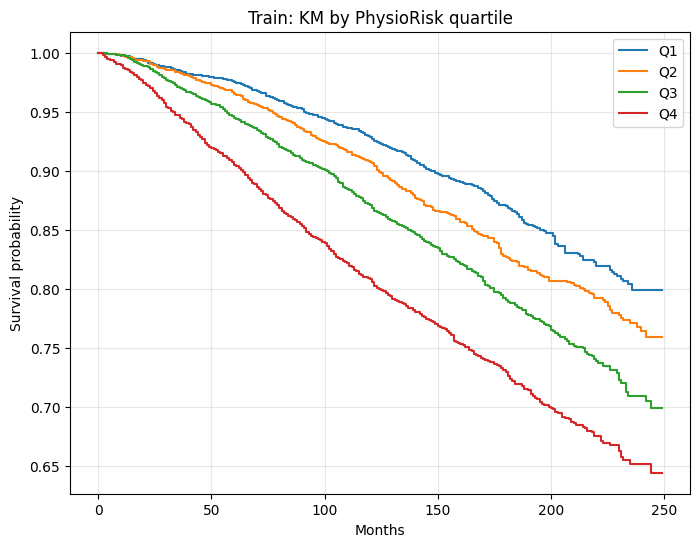

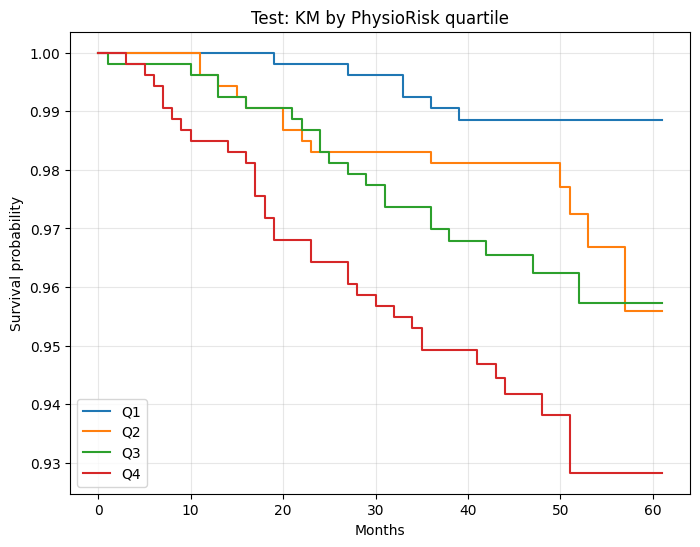

saved: /content/drive/MyDrive/LRE/data/pub/benchmark_physiorisk_v1_train_scored.parquet
saved: /content/drive/MyDrive/LRE/data/pub/benchmark_physiorisk_v1_test_scored.parquet
saved: /content/drive/MyDrive/LRE/data/pub/benchmark_physiorisk_v1_metrics.csv


In [33]:
# ============================================================
# Phase 2D — Assemble scored cohorts, evaluate, and save
# ============================================================

train_scored = train_scoring[[ID_COL, TIME_COL, EVENT_COL, AGE_COL, SEX_COL, CYCLE_COL]].copy()
test_scored  = test_scoring[[ID_COL, TIME_COL, EVENT_COL, AGE_COL, SEX_COL, CYCLE_COL]].copy()

train_scored = pd.concat([train_scored, baseline_train, physio_train], axis=1)
test_scored  = pd.concat([test_scored, baseline_test, physio_test], axis=1)

train_scored["TotalRisk"] = train_scored["BaselineRisk"] + train_scored["PhysioRisk"]
test_scored["TotalRisk"]  = test_scored["BaselineRisk"] + test_scored["PhysioRisk"]

rows = []
for cohort_name, dfx in [("train_benchmark", train_scored), ("test_benchmark", test_scored)]:
    for score_col in ["BaselineRisk", "PhysioRisk", "TotalRisk"]:
        out = evaluate_score(dfx, score_col)
        out["cohort"] = cohort_name
        rows.append(out)

metrics_df = pd.DataFrame(rows)[[
    "cohort", "risk_score", "C_index", "HR_per_1SD",
    "HR_95CI_low", "HR_95CI_high", "corr_age"
]].sort_values(["cohort", "risk_score"]).reset_index(drop=True)

print("Scored cohort sizes")
print("train_scored:", train_scored.shape, "deaths:", int(train_scored[EVENT_COL].sum()))
print("test_scored :", test_scored.shape,  "deaths:", int(test_scored[EVENT_COL].sum()))

display(metrics_df)

# optional sanity plots
plot_km_by_quartile(train_scored, "PhysioRisk", "Train: KM by PhysioRisk quartile")
plot_km_by_quartile(test_scored, "PhysioRisk", "Test: KM by PhysioRisk quartile")

# save
train_scored.to_parquet(OUT_TRAIN_FP, index=False)
test_scored.to_parquet(OUT_TEST_FP, index=False)
metrics_df.to_csv(OUT_METRICS_FP, index=False)

print("saved:", OUT_TRAIN_FP)
print("saved:", OUT_TEST_FP)
print("saved:", OUT_METRICS_FP)